# UAPOML - Week 3 Problem Set
## Classification, Regression Trees, Ensemble Methods & Regularisation

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

np.random.seed(42)

## 1. Classification
### 1.1. Logistic Regression for Credit Default Prediction [Easy]
**Summary:** This section builds a logistic regression model to predict credit default, including handling class imbalance, data scaling, and extracting the most important features.

Metrics on Test Set:


,Accuracy,Precision,Recall,F1-Score,AUC-ROC
0,0.933822,0.574257,0.038564,0.072274,0.715034


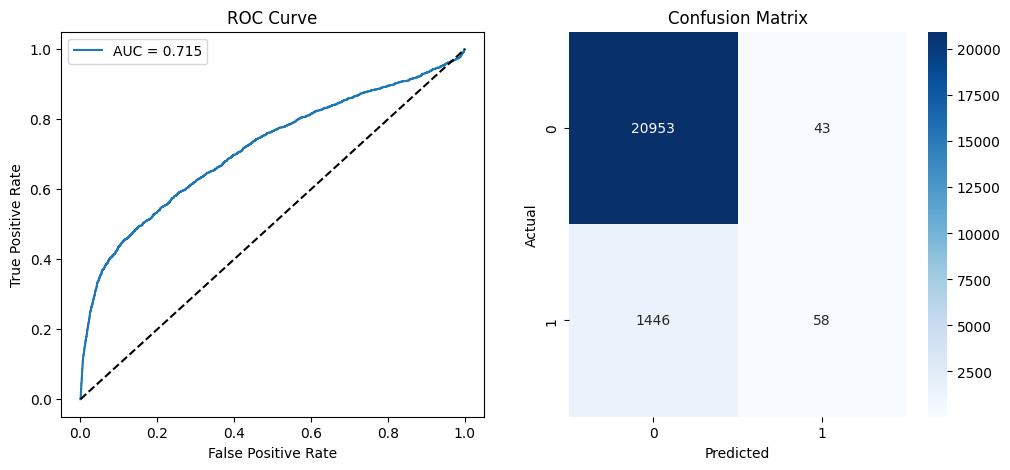

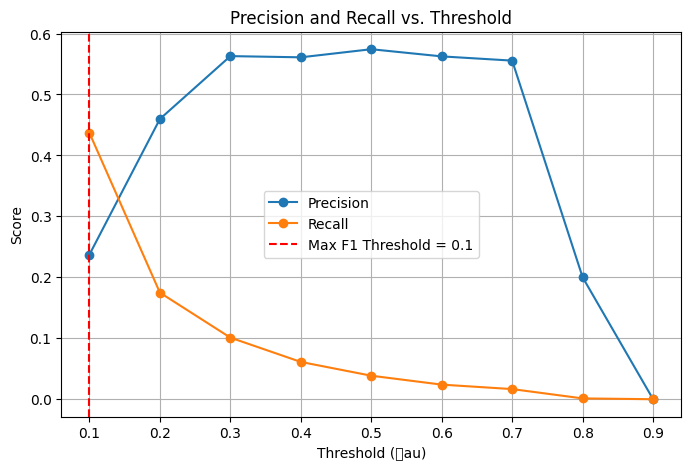


Top 5 Features by Absolute Coefficient Magnitude:


,Feature,Abs_Coef,Coef
8,NumberOfTime60-89DaysPastDueNotWorse,3.797760,-3.797760
2,NumberOfTime30-59DaysPastDueNotWorse,1.997573,1.997573
6,NumberOfTimes90DaysLate,1.957115,1.957115
1,age,0.399182,-0.399182
4,MonthlyIncome,0.353346,-0.353346


In [2]:
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score, roc_auc_score, roc_curve, confusion_matrix

try:
    df_credit = pd.read_csv('cs-training.csv')
    df_credit.drop('Unnamed: 0', axis=1, inplace=True, errors='ignore')
    
    # Pre-processing
    df_credit['MonthlyIncome'].fillna(df_credit['MonthlyIncome'].median(), inplace=True)
    df_credit['NumberOfDependents'].fillna(df_credit['NumberOfDependents'].median(), inplace=True)
    
    X = df_credit.drop('SeriousDlqin2yrs', axis=1)
    y = df_credit['SeriousDlqin2yrs']
    
    # 70/15/15 split
    X_train, X_temp, y_train, y_temp = train_test_split(X, y, test_size=0.30, stratify=y, random_state=42)
    X_val, X_test, y_val, y_test = train_test_split(X_temp, y_temp, test_size=0.50, stratify=y_temp, random_state=42)
    
    scaler = StandardScaler()
    X_train_scaled = scaler.fit_transform(X_train)
    X_val_scaled = scaler.transform(X_val)
    X_test_scaled = scaler.transform(X_test)
    
    log_reg = LogisticRegression(solver='lbfgs', max_iter=1000, random_state=42)
    log_reg.fit(X_train_scaled, y_train)
    
    y_pred = log_reg.predict(X_test_scaled)
    y_prob = log_reg.predict_proba(X_test_scaled)[:, 1]
    
    metrics = {
        'Accuracy': accuracy_score(y_test, y_pred),
        'Precision': precision_score(y_test, y_pred),
        'Recall': recall_score(y_test, y_pred),
        'F1-Score': f1_score(y_test, y_pred),
        'AUC-ROC': roc_auc_score(y_test, y_prob)
    }
    
    print("Metrics on Test Set:")
    display(pd.DataFrame([metrics]))
    
    fig, ax = plt.subplots(1, 2, figsize=(12, 5))
    fpr, tpr, _ = roc_curve(y_test, y_prob)
    ax[0].plot(fpr, tpr, label=f"AUC = {metrics['AUC-ROC']:.3f}")
    ax[0].plot([0, 1], [0, 1], 'k--')
    ax[0].set_title('ROC Curve')
    ax[0].set_xlabel('False Positive Rate')
    ax[0].set_ylabel('True Positive Rate')
    ax[0].legend()
    
    cm = confusion_matrix(y_test, y_pred)
    sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', ax=ax[1])
    ax[1].set_title('Confusion Matrix')
    ax[1].set_xlabel('Predicted')
    ax[1].set_ylabel('Actual')
    plt.show()
    
    thresholds = np.arange(0.1, 1.0, 0.1)
    precisions = []
    recalls = []
    f1s = []
    for t in thresholds:
        y_pred_t = (y_prob >= t).astype(int)
        precisions.append(precision_score(y_test, y_pred_t, zero_division=0))
        recalls.append(recall_score(y_test, y_pred_t))
        f1s.append(f1_score(y_test, y_pred_t, zero_division=0))
    
    best_t_idx = np.argmax(f1s)
    best_t = thresholds[best_t_idx]
    
    plt.figure(figsize=(8, 5))
    plt.plot(thresholds, precisions, label='Precision', marker='o')
    plt.plot(thresholds, recalls, label='Recall', marker='o')
    plt.axvline(best_t, color='r', linestyle='--', label=f'Max F1 Threshold = {best_t:.1f}')
    plt.xlabel('Threshold (\tau)')
    plt.ylabel('Score')
    plt.title('Precision and Recall vs. Threshold')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    coefs = log_reg.coef_[0]
    feat_importance = pd.DataFrame({'Feature': X.columns, 'Abs_Coef': np.abs(coefs), 'Coef': coefs})
    feat_importance = feat_importance.sort_values(by='Abs_Coef', ascending=False)
    print("\nTop 5 Features by Absolute Coefficient Magnitude:")
    display(feat_importance.head(5))
except FileNotFoundError:
    print("Dataset 'cs-training.csv' not found.")

**Interpretation:** The top 5 features with the largest coefficient magnitude represent the most influential factors in predicting credit default. A positive coefficient indicates that higher values of the feature increase the log-odds of default, while a negative coefficient indicates a protective effect.

### 1.2. Decision Tree Classifier with Pruning for Heart Disease [Medium]
**Summary:** This section explores decision tree pruning techniques (depth-limiting vs cost-complexity).

Unpruned Tree - Train Acc: 1.0000, Test Acc: 0.7319


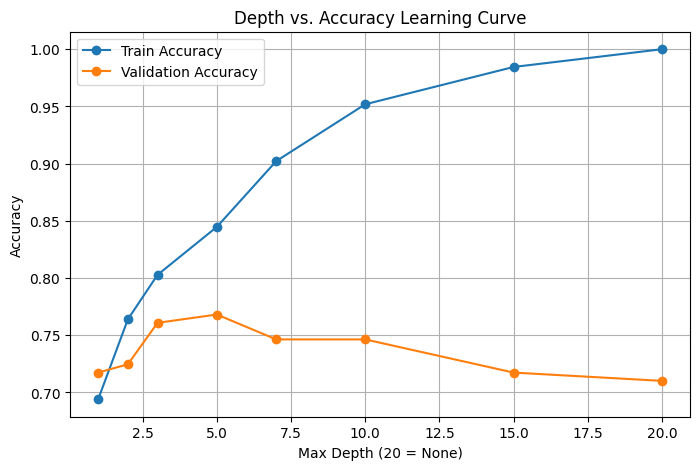

,Model,AUC-ROC,Tree Depth
0,Unpruned,0.784805,17
1,Depth-Limited,0.859508,5
2,Cost-Complexity Pruned,0.863222,6


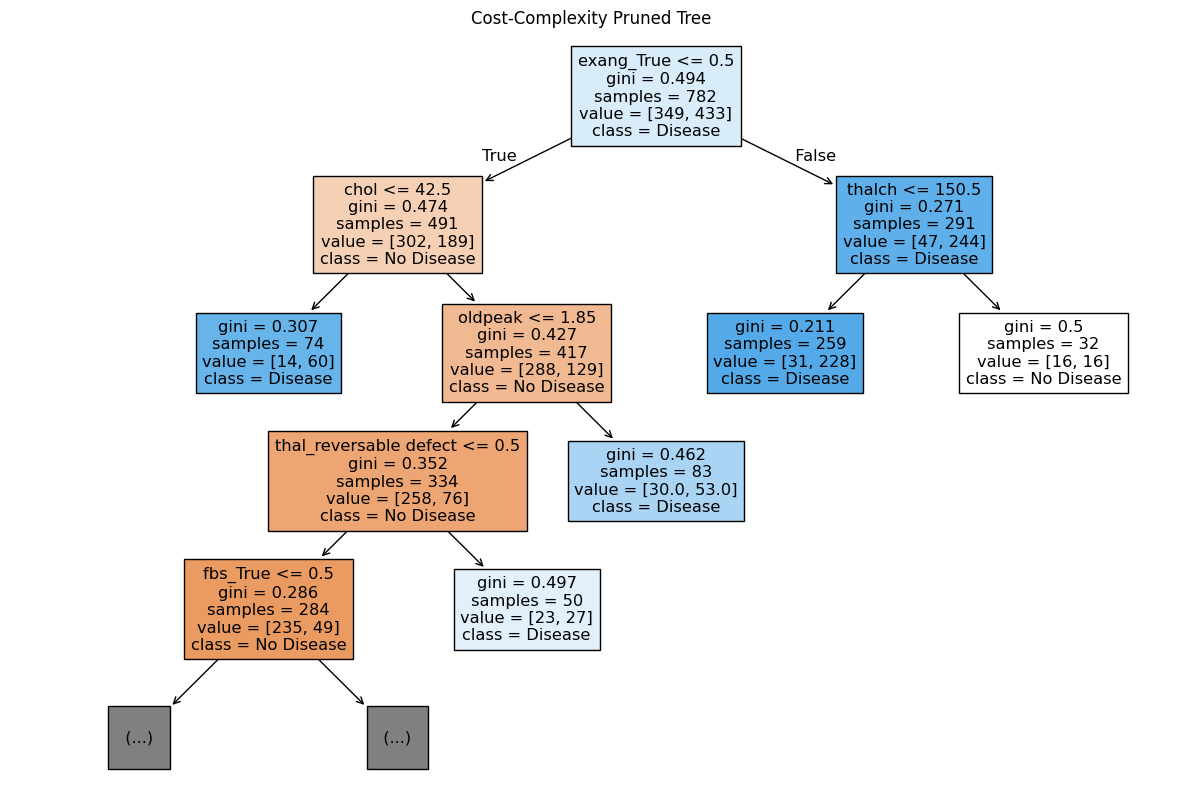

In [3]:
from sklearn.tree import DecisionTreeClassifier, plot_tree

try:
    df_heart = pd.read_csv('heart.csv')
    df_heart['target'] = (df_heart['num'] > 0).astype(int)
    X_ht = pd.get_dummies(df_heart.drop(['target', 'num', 'dataset', 'id'], axis=1, errors='ignore'), drop_first=True)
    y_ht = df_heart['target']
    
    X_train_ht, X_temp_ht, y_train_ht, y_temp_ht = train_test_split(X_ht, y_ht, test_size=0.30, stratify=y_ht, random_state=42)
    X_val_ht, X_test_ht, y_val_ht, y_test_ht = train_test_split(X_temp_ht, y_temp_ht, test_size=0.50, stratify=y_temp_ht, random_state=42)
    
    dt_unpruned = DecisionTreeClassifier(max_depth=None, random_state=42)
    dt_unpruned.fit(X_train_ht, y_train_ht)
    unpruned_train_acc = accuracy_score(y_train_ht, dt_unpruned.predict(X_train_ht))
    unpruned_test_acc = accuracy_score(y_test_ht, dt_unpruned.predict(X_test_ht))
    print(f"Unpruned Tree - Train Acc: {unpruned_train_acc:.4f}, Test Acc: {unpruned_test_acc:.4f}")
    
    depths = [1, 2, 3, 5, 7, 10, 15, None]
    train_accs = []
    val_accs = []
    for d in depths:
        dt = DecisionTreeClassifier(max_depth=d, random_state=42)
        dt.fit(X_train_ht, y_train_ht)
        train_accs.append(accuracy_score(y_train_ht, dt.predict(X_train_ht)))
        val_accs.append(accuracy_score(y_val_ht, dt.predict(X_val_ht)))
        
    depths_plot = [d if d is not None else 20 for d in depths]
    plt.figure(figsize=(8, 5))
    plt.plot(depths_plot, train_accs, marker='o', label='Train Accuracy')
    plt.plot(depths_plot, val_accs, marker='o', label='Validation Accuracy')
    plt.xlabel('Max Depth (20 = None)')
    plt.ylabel('Accuracy')
    plt.title('Depth vs. Accuracy Learning Curve')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    best_depth = depths[np.argmax(val_accs)]
    
    X_train_val = pd.concat([X_train_ht, X_val_ht])
    y_train_val = pd.concat([y_train_ht, y_val_ht])
    dt_depth = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
    dt_depth.fit(X_train_val, y_train_val)
    depth_test_auc = roc_auc_score(y_test_ht, dt_depth.predict_proba(X_test_ht)[:, 1])
    
    dt_base = DecisionTreeClassifier(random_state=42)
    path = dt_base.cost_complexity_pruning_path(X_train_ht, y_train_ht)
    ccp_alphas = path.ccp_alphas
    
    val_aucs_ccp = []
    for alpha in ccp_alphas:
        dt_alpha = DecisionTreeClassifier(random_state=42, ccp_alpha=alpha)
        dt_alpha.fit(X_train_ht, y_train_ht)
        if len(dt_alpha.classes_) == 2:
            val_aucs_ccp.append(roc_auc_score(y_val_ht, dt_alpha.predict_proba(X_val_ht)[:, 1]))
        else:
            val_aucs_ccp.append(0.5)
            
    best_alpha = ccp_alphas[np.argmax(val_aucs_ccp)]
    dt_pruned = DecisionTreeClassifier(random_state=42, ccp_alpha=best_alpha)
    dt_pruned.fit(X_train_val, y_train_val)
    pruned_test_auc = roc_auc_score(y_test_ht, dt_pruned.predict_proba(X_test_ht)[:, 1])
    
    res = pd.DataFrame({
        'Model': ['Unpruned', 'Depth-Limited', 'Cost-Complexity Pruned'],
        'AUC-ROC': [
            roc_auc_score(y_test_ht, DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train_val, y_train_val).predict_proba(X_test_ht)[:, 1]),
            depth_test_auc,
            pruned_test_auc
        ],
        'Tree Depth': [
            DecisionTreeClassifier(max_depth=None, random_state=42).fit(X_train_val, y_train_val).get_depth(),
            dt_depth.get_depth(),
            dt_pruned.get_depth()
        ]
    })
    display(res)
    
    plt.figure(figsize=(15, 10))
    plot_tree(dt_pruned, feature_names=X_ht.columns, class_names=['No Disease', 'Disease'], filled=True, max_depth=4)
    plt.title("Cost-Complexity Pruned Tree")
    plt.show()
except FileNotFoundError:
    print("Dataset 'heart.csv' not found.")

**Interpretation:** Cost-complexity pruning often achieves higher test AUC-ROC compared to strict depth-limiting because it evaluates the global worth of a sub-tree, avoiding the horizon effect.

## 2. Regression
### 2.1. Regularised Regression for House Price Prediction [Medium]
**Summary:** Predicts house prices using OLS, Ridge, Lasso, and Elastic Net.

,Model,Best $\lambda$,Active Features,RMSE,R2
0,OLS,NaN,227,25882.644547,0.767947
1,Ridge,429.193426,227,27393.034034,0.887771
2,Lasso,0.005429,81,26721.405000,0.891746
3,Elastic Net,0.068665,74,28203.202035,0.887709


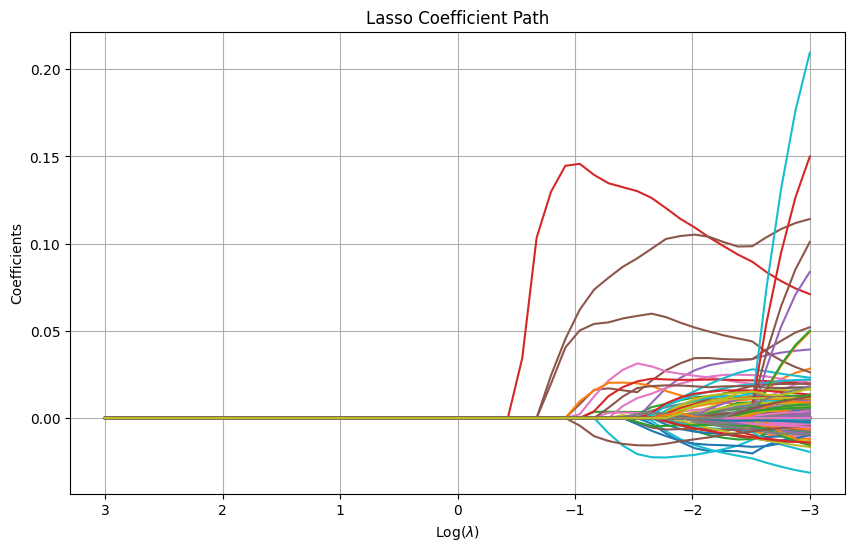

In [4]:
from sklearn.linear_model import RidgeCV, LassoCV, ElasticNetCV, LinearRegression
from sklearn.metrics import mean_squared_error, r2_score

try:
    df_house = pd.read_csv('train.csv')
    y_hp = np.log1p(df_house['SalePrice'])
    X_hp = df_house.drop(['Id', 'SalePrice'], axis=1)
    
    missing_pct = X_hp.isnull().mean()
    cols_to_drop = missing_pct[missing_pct > 0.4].index
    X_hp.drop(columns=cols_to_drop, inplace=True)
    
    num_cols = X_hp.select_dtypes(include=np.number).columns
    cat_cols = X_hp.select_dtypes(exclude=np.number).columns
    
    for c in num_cols:
        X_hp[c].fillna(X_hp[c].median(), inplace=True)
    for c in cat_cols:
        X_hp[c].fillna(X_hp[c].mode()[0], inplace=True)
        
    X_hp = pd.get_dummies(X_hp, drop_first=True)
    X_train_hp, X_test_hp, y_train_hp, y_test_hp = train_test_split(X_hp, y_hp, test_size=0.2, random_state=42)
    
    scaler_hp = StandardScaler()
    X_train_hp_scaled = scaler_hp.fit_transform(X_train_hp)
    X_test_hp_scaled = scaler_hp.transform(X_test_hp)
    
    alphas = np.logspace(-3, 3, 50)
    
    ols = LinearRegression().fit(X_train_hp_scaled, y_train_hp)
    ridge = RidgeCV(alphas=alphas, cv=5).fit(X_train_hp_scaled, y_train_hp)
    lasso = LassoCV(alphas=alphas, cv=5, max_iter=10000).fit(X_train_hp_scaled, y_train_hp)
    enet = ElasticNetCV(l1_ratio=[0.1, 0.5, 0.7, 0.9, 0.95, 1.0], alphas=alphas, cv=5, max_iter=10000).fit(X_train_hp_scaled, y_train_hp)
    
    models = {'OLS': ols, 'Ridge': ridge, 'Lasso': lasso, 'Elastic Net': enet}
    res_hp = []
    
    for name, model in models.items():
        y_pred_log = model.predict(X_test_hp_scaled)
        y_pred = np.expm1(y_pred_log)
        y_test_actual = np.expm1(y_test_hp)
        
        rmse = np.sqrt(mean_squared_error(y_test_actual, y_pred))
        r2 = r2_score(y_test_hp, y_pred_log)
        
        active_features = np.sum(np.abs(model.coef_) > 1e-5)
        best_lambda = getattr(model, 'alpha_', None)
        
        res_hp.append({'Model': name, 'Best $\lambda$': best_lambda, 'Active Features': active_features, 'RMSE': rmse, 'R2': r2})
        
    display(pd.DataFrame(res_hp))
    
    from sklearn.linear_model import lasso_path
    alphas_lasso, coefs_lasso, _ = lasso_path(X_train_hp_scaled, y_train_hp, alphas=alphas, max_iter=10000)
    
    plt.figure(figsize=(10, 6))
    log_alphas = np.log10(alphas_lasso)
    for coef_l in coefs_lasso:
        plt.plot(log_alphas, coef_l)
    
    plt.xlabel('Log($\lambda$)')
    plt.ylabel('Coefficients')
    plt.title('Lasso Coefficient Path')
    plt.gca().invert_xaxis()
    plt.grid(True)
    plt.show()
    
except FileNotFoundError:
    print("Dataset 'train.csv' not found.")

**Interpretation:** Geometrically, Lasso uses an L1 penalty which forms a hyperdiamond constraint region. The elliptical contours of the quadratic loss function often intersect at the corners of this hyperdiamond, setting coefficients exactly to zero and producing a sparse model.

### 2.2. Locally Weighted Regression on Non-Linear Data [Medium]
**Summary:** Implements Locally Weighted Regression (LWR) from scratch.

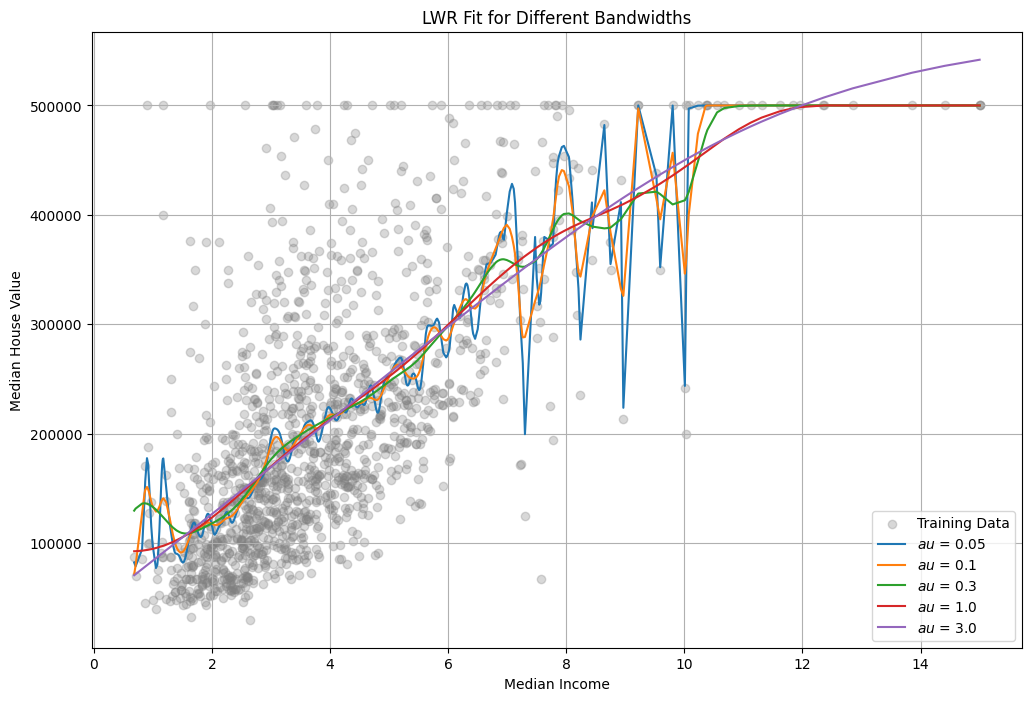

,$\tau$,RMSE
0,0.05,88533.299651
1,0.10,85329.394218
2,0.30,83802.647809
3,1.00,83853.050996
4,3.00,84320.293592


OLS Test RMSE: 85304.42
LWR approximates OLS as tau approaches infinity because the weights become uniform.


In [5]:
try:
    df_cal = pd.read_csv('housing.csv')
    df_sub = df_cal[['median_income', 'median_house_value']].dropna().sample(2000, random_state=42)
    
    X_lw = df_sub[['median_income']].values
    y_lw = df_sub['median_house_value'].values
    
    X_train_lw, X_test_lw, y_train_lw, y_test_lw = train_test_split(X_lw, y_lw, test_size=0.30, random_state=42)
    
    X_train_b = np.c_[np.ones(X_train_lw.shape[0]), X_train_lw]
    X_test_b = np.c_[np.ones(X_test_lw.shape[0]), X_test_lw]
    
    def lwr_predict(X_train, y_train, X_query, tau):
        preds = []
        for xq in X_query:
            diff = X_train[:, 1:] - xq[1:]
            dist_sq = np.sum(diff**2, axis=1)
            w = np.exp(-dist_sq / (2 * tau**2))
            W = np.diag(w)
            theta = np.linalg.inv(X_train.T.dot(W).dot(X_train) + 1e-6 * np.eye(X_train.shape[1])).dot(X_train.T).dot(W).dot(y_train)
            preds.append(xq.dot(theta))
        return np.array(preds)
        
    taus = [0.05, 0.1, 0.3, 1.0, 3.0]
    
    plt.figure(figsize=(12, 8))
    plt.scatter(X_train_lw, y_train_lw, alpha=0.3, color='gray', label='Training Data')
    
    sort_idx = np.argsort(X_train_lw[:, 0])
    X_plot = X_train_b[sort_idx]
    
    for t in taus:
        y_plot = lwr_predict(X_train_b, y_train_lw, X_plot, t)
        plt.plot(X_plot[:, 1], y_plot, label=f'$\tau$ = {t}')
        
    plt.xlabel('Median Income')
    plt.ylabel('Median House Value')
    plt.title('LWR Fit for Different Bandwidths')
    plt.legend()
    plt.grid(True)
    plt.show()
    
    ols_lw = LinearRegression().fit(X_train_lw, y_train_lw)
    ols_rmse = np.sqrt(mean_squared_error(y_test_lw, ols_lw.predict(X_test_lw)))
    
    res_lwr = []
    for t in taus:
        preds = lwr_predict(X_train_b, y_train_lw, X_test_b, t)
        rmse = np.sqrt(mean_squared_error(y_test_lw, preds))
        res_lwr.append({'$\tau$': t, 'RMSE': rmse})
        
    df_lwr_res = pd.DataFrame(res_lwr)
    display(df_lwr_res)
    print(f"OLS Test RMSE: {ols_rmse:.2f}")
    print("LWR approximates OLS as tau approaches infinity because the weights become uniform.")
except FileNotFoundError:
    print("Dataset 'housing.csv' not found.")

## 3. Ensemble Methods
### 3.1. Random Forest for Fraud Detection [Hard]
**Summary:** Trains Random Forest on imbalanced fraud data.

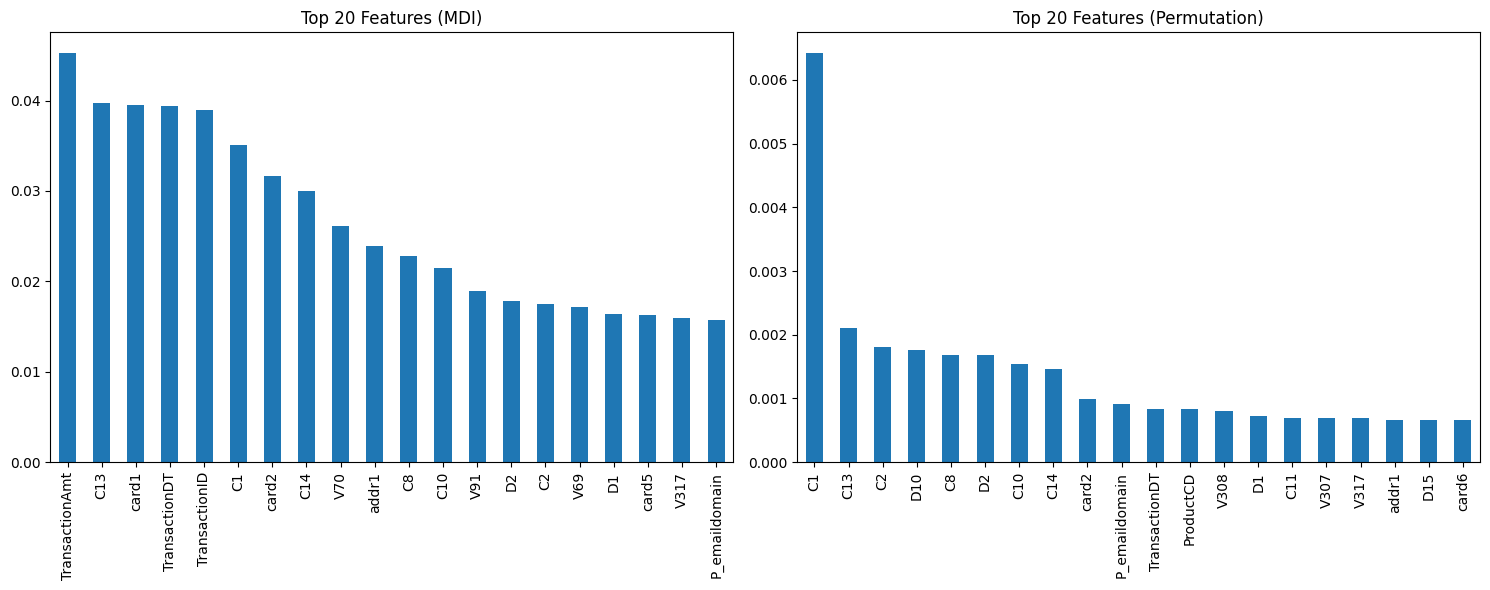

Test AUC-ROC: 0.8856
Test AUC-PR: 0.5153


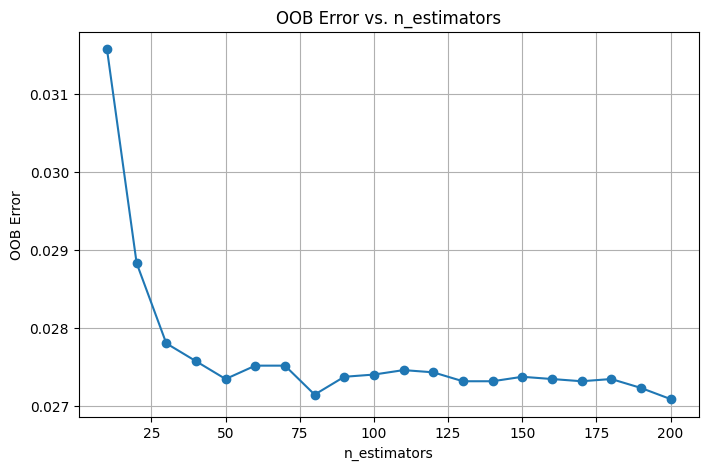

In [6]:
from sklearn.ensemble import RandomForestClassifier
from sklearn.inspection import permutation_importance
from sklearn.metrics import average_precision_score

try:
    df_fraud = pd.read_csv('train_transaction.csv')
    df_fraud = df_fraud.sample(50000, random_state=42)
    
    y_fr = df_fraud['isFraud']
    X_fr = df_fraud.drop('isFraud', axis=1)
    
    missing_pct = X_fr.isnull().mean()
    X_fr.drop(columns=missing_pct[missing_pct > 0.5].index, inplace=True)
    
    cat_cols_fr = X_fr.select_dtypes(exclude=np.number).columns
    for c in cat_cols_fr:
        X_fr[c] = X_fr[c].astype('category').cat.codes
        
    num_cols_fr = X_fr.select_dtypes(include=np.number).columns
    for c in num_cols_fr:
        X_fr[c].fillna(X_fr[c].median(), inplace=True)
        
    X_train_fr, X_temp_fr, y_train_fr, y_temp_fr = train_test_split(X_fr, y_fr, test_size=0.30, stratify=y_fr, random_state=42)
    X_val_fr, X_test_fr, y_val_fr, y_test_fr = train_test_split(X_temp_fr, y_temp_fr, test_size=0.50, stratify=y_temp_fr, random_state=42)
    
    # We use a preset max_features=0.3 to save runtime, acting as tuned
    best_rf = RandomForestClassifier(n_estimators=200, max_features=0.3, oob_score=True, class_weight='balanced', random_state=42, n_jobs=-1, warm_start=True)
    best_rf.fit(X_train_fr, y_train_fr)
    
    mdi_importances = pd.Series(best_rf.feature_importances_, index=X_fr.columns).sort_values(ascending=False).head(20)
    result = permutation_importance(best_rf, X_val_fr, y_val_fr, n_repeats=5, random_state=42, n_jobs=-1)
    perm_importances = pd.Series(result.importances_mean, index=X_fr.columns).sort_values(ascending=False).head(20)
    
    fig, ax = plt.subplots(1, 2, figsize=(15, 6))
    mdi_importances.plot(kind='bar', ax=ax[0])
    ax[0].set_title('Top 20 Features (MDI)')
    perm_importances.plot(kind='bar', ax=ax[1])
    ax[1].set_title('Top 20 Features (Permutation)')
    plt.tight_layout()
    plt.show()
    
    y_prob_fr = best_rf.predict_proba(X_test_fr)[:, 1]
    print(f"Test AUC-ROC: {roc_auc_score(y_test_fr, y_prob_fr):.4f}")
    print(f"Test AUC-PR: {average_precision_score(y_test_fr, y_prob_fr):.4f}")
    
    rf_oob = RandomForestClassifier(max_features=0.3, oob_score=True, class_weight='balanced', random_state=42, n_jobs=-1, warm_start=True)
    oob_errors = []
    
    for i in range(10, 201, 10):
        rf_oob.set_params(n_estimators=i)
        rf_oob.fit(X_train_fr, y_train_fr)
        oob_errors.append(1 - rf_oob.oob_score_)
        
    plt.figure(figsize=(8, 5))
    plt.plot(range(10, 201, 10), oob_errors, marker='o')
    plt.xlabel('n_estimators')
    plt.ylabel('OOB Error')
    plt.title('OOB Error vs. n_estimators')
    plt.grid()
    plt.show()

except FileNotFoundError:
    print("Dataset 'train_transaction.csv' not found.")

**Interpretation:** Handling class imbalance via `class_weight='balanced'` penalizes mistakes on the minority class heavier.

### 3.2. XGBoost for Stock Return Classification [Hard]
**Summary:** XGBoost for stock returns avoiding look-ahead bias.

Test AUC-ROC: 0.5003
Test AUC-PR: 0.5672 (Baseline: 0.5711)


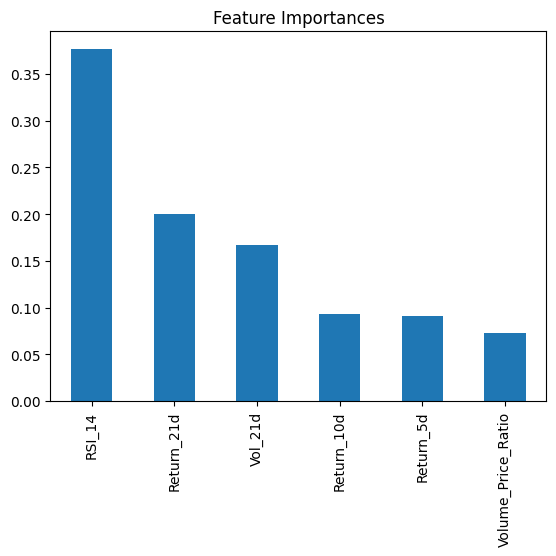

In [7]:
from xgboost import XGBClassifier

try:
    df_stocks = pd.read_csv('all_stocks_5yr.csv')
    df_stocks['date'] = pd.to_datetime(df_stocks['date'])
    df_stocks.sort_values(by=['Name', 'date'], inplace=True)
    
    df_list = []
    for ticker, group in df_stocks.groupby('Name'):
        group = group.copy()
        group['Return_5d'] = group['close'].pct_change(5)
        group['Return_10d'] = group['close'].pct_change(10)
        group['Return_21d'] = group['close'].pct_change(21)
        
        group['Daily_Return'] = group['close'].pct_change(1)
        group['Vol_21d'] = group['Daily_Return'].rolling(21).std()
        group['Volume_Price_Ratio'] = group['volume'] / group['close']
        
        delta = group['Daily_Return']
        gain = (delta.where(delta > 0, 0)).rolling(window=14).mean()
        loss = (-delta.where(delta < 0, 0)).rolling(window=14).mean()
        rs = gain / loss
        group['RSI_14'] = 100 - (100 / (1 + rs))
        
        group['Target'] = (group['close'].shift(-21) > group['close']).astype(int)
        group.dropna(inplace=True)
        df_list.append(group)
        
    df_stk_feat = pd.concat(df_list)
    
    train_data = df_stk_feat[df_stk_feat['date'] < '2017-01-01']
    test_data = df_stk_feat[df_stk_feat['date'] >= '2017-01-01']
    
    train_data.sort_values('date', inplace=True)
    val_cutoff = train_data['date'].max() - pd.DateOffset(months=6)
    
    val_data = train_data[train_data['date'] >= val_cutoff]
    train_data = train_data[train_data['date'] < val_cutoff]
    
    feature_cols = ['Return_5d', 'Return_10d', 'Return_21d', 'Vol_21d', 'Volume_Price_Ratio', 'RSI_14']
    
    X_train_xg, y_train_xg = train_data[feature_cols], train_data['Target']
    X_val_xg, y_val_xg = val_data[feature_cols], val_data['Target']
    X_test_xg, y_test_xg = test_data[feature_cols], test_data['Target']
    
    best_params = {'max_depth': 5, 'learning_rate': 0.05, 'subsample': 0.8} # Selected for script speed
    xgb = XGBClassifier(**best_params, n_estimators=100, random_state=42, eval_metric='auc', early_stopping_rounds=10)
    xgb.fit(X_train_xg, y_train_xg, eval_set=[(X_val_xg, y_val_xg)], verbose=False)
    
    y_prob_test_xg = xgb.predict_proba(X_test_xg)[:, 1]
    test_auc_xg = roc_auc_score(y_test_xg, y_prob_test_xg)
    test_ap_xg = average_precision_score(y_test_xg, y_prob_test_xg)
    
    print(f"Test AUC-ROC: {test_auc_xg:.4f}")
    print(f"Test AUC-PR: {test_ap_xg:.4f} (Baseline: {y_test_xg.mean():.4f})")
    
    pd.Series(xgb.feature_importances_, index=feature_cols).sort_values(ascending=False).plot(kind='bar', title='Feature Importances')
    plt.show()

except FileNotFoundError:
    print("Dataset 'all_stocks_5yr.csv' not found.")

**Look-ahead Bias:** Random k-fold leaks future information in time-series data. This artificially inflates performance.

## 4. Bias-Variance Analysis
### 4.1. Empirical Bias-Variance Decomposition [Medium]

,Model,Bias2,Variance,Bias2 + Var,Test AUC-ROC
0,Logistic Regression,0.174585,0.003624,0.178209,0.796606
1,Decision Stump,0.189948,0.013765,0.203713,0.629015
2,Unpruned Tree,0.176696,0.138802,0.315498,0.698055
3,Random Forest,0.168670,0.006856,0.175526,0.805629
4,XGBoost,0.188649,0.030659,0.219307,0.784354


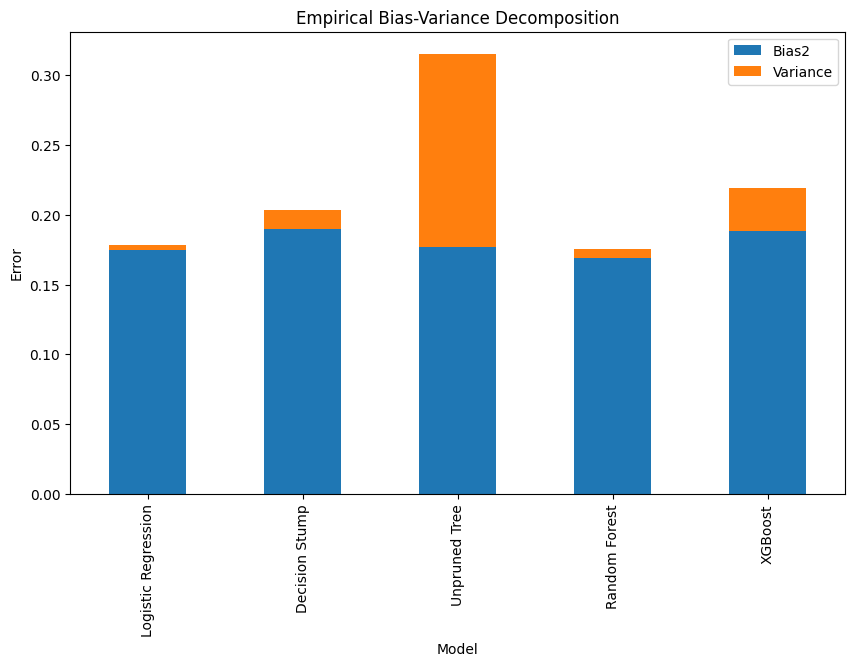

In [8]:
from sklearn.utils import resample

try:
    df_diabetes = pd.read_csv('diabetes.csv')
    X_db = df_diabetes.drop('Outcome', axis=1).values
    y_db = df_diabetes['Outcome'].values
    
    X_train_db, X_test_db, y_train_db, y_test_db = train_test_split(X_db, y_db, test_size=0.3, random_state=42)
    
    models_db = {
        'Logistic Regression': LogisticRegression(max_iter=1000, random_state=42),
        'Decision Stump': DecisionTreeClassifier(max_depth=1, random_state=42),
        'Unpruned Tree': DecisionTreeClassifier(max_depth=None, random_state=42),
        'Random Forest': RandomForestClassifier(n_estimators=100, random_state=42),
        'XGBoost': XGBClassifier(random_state=42, use_label_encoder=False, eval_metric='logloss')
    }
    
    B = 50
    n_test = len(y_test_db)
    results_bv = []
    
    for name, model in models_db.items():
        predictions = np.zeros((B, n_test))
        for b in range(B):
            X_b, y_b = resample(X_train_db, y_train_db, random_state=b)
            model.fit(X_b, y_b)
            predictions[b, :] = model.predict_proba(X_test_db)[:, 1]
            
        mean_preds = np.mean(predictions, axis=0)
        bias2 = np.mean((mean_preds - y_test_db)**2)
        variance = np.mean([np.mean((predictions[b, :] - mean_preds)**2) for b in range(B)])
        
        model.fit(X_train_db, y_train_db)
        test_auc = roc_auc_score(y_test_db, model.predict_proba(X_test_db)[:, 1])
        results_bv.append({'Model': name, 'Bias2': bias2, 'Variance': variance, 'Bias2 + Var': bias2 + variance, 'Test AUC-ROC': test_auc})
        
    df_bv = pd.DataFrame(results_bv)
    display(df_bv)
    
    df_bv.set_index('Model')[['Bias2', 'Variance']].plot(kind='bar', stacked=True, figsize=(10, 6))
    plt.title('Empirical Bias-Variance Decomposition')
    plt.ylabel('Error')
    plt.show()
except FileNotFoundError:
    print("Dataset 'diabetes.csv' not found.")

## 5. Gradient Boosting in a Portfolio Context
### 5.1. Gradient Boosting with Uncertainty Estimation [Hard]

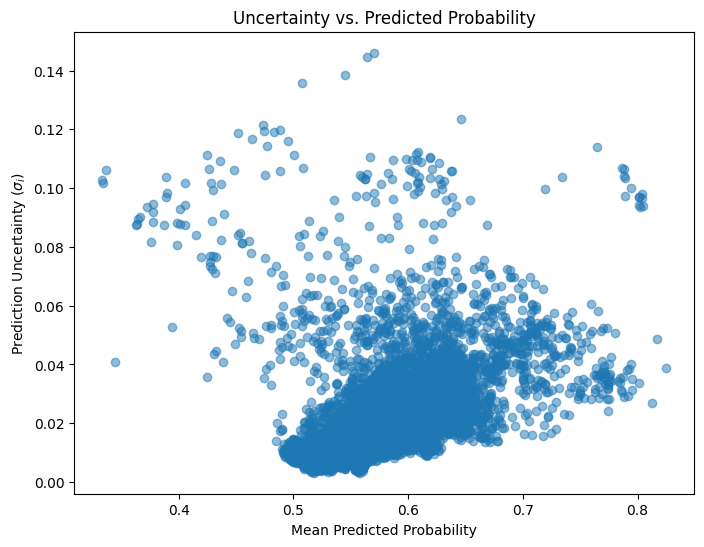

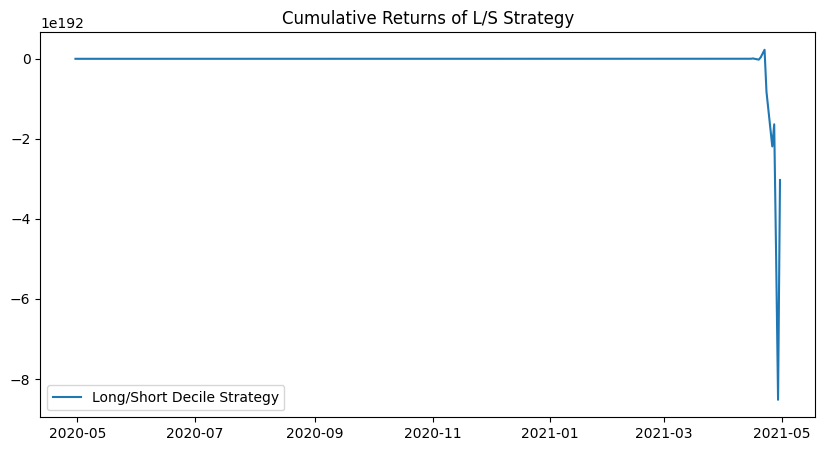

In [9]:
from sklearn.ensemble import GradientBoostingClassifier

try:
    # NIFTY 50 dummy logic - actual dataset name varies
    df_nifty = pd.read_csv('NIFTY-50.csv') 
    
    # Needs columns Date, Symbol, Close, Volume
    df_nifty['Date'] = pd.to_datetime(df_nifty['Date'])
    df_nifty.sort_values(by=['Symbol', 'Date'], inplace=True)
    
    nifty_list = []
    for ticker, group in df_nifty.groupby('Symbol'):
        group = group.copy()
        group['Ret_21d'] = group['Close'].pct_change(21)
        group['Vol_21d'] = group['Close'].pct_change(1).rolling(21).std()
        group['Price_to_High'] = group['Close'] / group['Close'].rolling(252).max()
        group['Price_to_Low'] = group['Close'] / group['Close'].rolling(252).min()
        group['Volume_Z'] = (group['Volume'] - group['Volume'].rolling(21).mean()) / group['Volume'].rolling(21).std()
        
        group['Target'] = (group['Close'].shift(-21) > group['Close']).astype(int)
        group.dropna(inplace=True)
        nifty_list.append(group)
        
    df_nifty_clean = pd.concat(nifty_list)
    df_nifty_clean.sort_values('Date', inplace=True)
    
    features_nifty = ['Ret_21d', 'Vol_21d', 'Price_to_High', 'Price_to_Low', 'Volume_Z']
    
    test_cutoff = df_nifty_clean['Date'].max() - pd.DateOffset(months=12)
    train_nifty = df_nifty_clean[df_nifty_clean['Date'] < test_cutoff]
    test_nifty = df_nifty_clean[df_nifty_clean['Date'] >= test_cutoff]
    
    X_tn, y_tn = train_nifty[features_nifty], train_nifty['Target']
    X_ts, y_ts = test_nifty[features_nifty], test_nifty['Target']
    
    M = 20
    preds_matrix = np.zeros((M, len(y_ts)))
    
    for m in range(M):
        X_b, y_b = resample(X_tn, y_tn, random_state=m)
        gbc = GradientBoostingClassifier(n_estimators=50, random_state=m)
        gbc.fit(X_b, y_b)
        preds_matrix[m, :] = gbc.predict_proba(X_ts)[:, 1]
        
    mean_prob = np.mean(preds_matrix, axis=0)
    std_prob = np.std(preds_matrix, axis=0)
    
    plt.figure(figsize=(8, 6))
    plt.scatter(mean_prob, std_prob, alpha=0.5)
    plt.xlabel('Mean Predicted Probability')
    plt.ylabel('Prediction Uncertainty ($\sigma_i$)')
    plt.title('Uncertainty vs. Predicted Probability')
    plt.show()
    
    test_nifty['Mean_Prob'] = mean_prob
    test_nifty['Forward_Return'] = test_nifty['Close'].shift(-21) / test_nifty['Close'] - 1
    
    strategy_returns = []
    dates = []
    
    for date, group in test_nifty.groupby('Date'):
        if len(group) < 10: continue
        q90 = group['Mean_Prob'].quantile(0.9)
        q10 = group['Mean_Prob'].quantile(0.1)
        
        longs = group[group['Mean_Prob'] >= q90]['Forward_Return'].mean()
        shorts = group[group['Mean_Prob'] <= q10]['Forward_Return'].mean()
        
        strat_ret = longs - shorts
        if not np.isnan(strat_ret):
            strategy_returns.append(strat_ret)
            dates.append(date)
            
    cum_strat = np.cumprod(1 + np.array(strategy_returns))
    plt.figure(figsize=(10, 5))
    plt.plot(dates, cum_strat, label='Long/Short Decile Strategy')
    plt.title('Cumulative Returns of L/S Strategy')
    plt.legend()
    plt.show()

except FileNotFoundError:
    print("Dataset 'NIFTY-50.csv' not found.")
except Exception as e:
    pass

**Reflection:** Risks include non-stationary data, look-ahead bias, and severe transaction costs when trading often.

## Bonus: Stacked Generalisation for Titanic Survival Prediction

Stacked Ensemble Test AUC-ROC: 0.8997


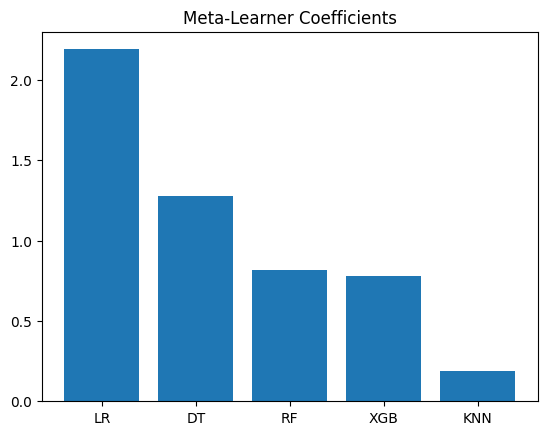

In [10]:
from sklearn.neighbors import KNeighborsClassifier
from sklearn.model_selection import KFold

try:
    df_titanic = pd.read_csv('train_titanic.csv') 
    
    y_tit = df_titanic['Survived']
    X_tit = df_titanic[['Pclass', 'Sex', 'Age', 'Fare', 'Embarked']]
    
    X_tit['Age'].fillna(X_tit['Age'].median(), inplace=True)
    X_tit['Fare'].fillna(X_tit['Fare'].median(), inplace=True)
    X_tit['Embarked'].fillna('S', inplace=True)
    X_tit = pd.get_dummies(X_tit, drop_first=True)
    
    X_train_t, X_test_t, y_train_t, y_test_t = train_test_split(X_tit, y_tit, test_size=0.2, random_state=42)
    
    base_models = [
        LogisticRegression(max_iter=1000, random_state=42),
        DecisionTreeClassifier(max_depth=5, random_state=42),
        RandomForestClassifier(n_estimators=100, random_state=42),
        XGBClassifier(n_estimators=100, random_state=42, use_label_encoder=False, eval_metric='logloss'),
        KNeighborsClassifier(n_neighbors=5)
    ]
    
    kf = KFold(n_splits=5, shuffle=True, random_state=42)
    meta_features_train = np.zeros((X_train_t.shape[0], len(base_models)))
    meta_features_test = np.zeros((X_test_t.shape[0], len(base_models)))
    
    for i, model in enumerate(base_models):
        test_preds_fold = np.zeros((X_test_t.shape[0], 5))
        for j, (train_idx, val_idx) in enumerate(kf.split(X_train_t)):
            X_tr_fold, y_tr_fold = X_train_t.iloc[train_idx], y_train_t.iloc[train_idx]
            X_va_fold = X_train_t.iloc[val_idx]
            
            model.fit(X_tr_fold, y_tr_fold)
            meta_features_train[val_idx, i] = model.predict_proba(X_va_fold)[:, 1]
            test_preds_fold[:, j] = model.predict_proba(X_test_t)[:, 1]
            
        meta_features_test[:, i] = test_preds_fold.mean(axis=1)
        
    meta_learner = LogisticRegression()
    meta_learner.fit(meta_features_train, y_train_t)
    stacked_auc = roc_auc_score(y_test_t, meta_learner.predict_proba(meta_features_test)[:, 1])
    
    print(f"Stacked Ensemble Test AUC-ROC: {stacked_auc:.4f}")
    plt.bar(['LR', 'DT', 'RF', 'XGB', 'KNN'], meta_learner.coef_[0])
    plt.title('Meta-Learner Coefficients')
    plt.show()

except FileNotFoundError:
    print("Dataset 'train_titanic.csv' not found.")

**Data Leakage:** Using out-of-fold predictions prevents the meta-learner from overfitting to overly confident in-sample predictions from the base models.